<a href="https://colab.research.google.com/github/pzedros/metodos_numericos/blob/main/trabalho_4_de_metodos1_questao1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 elimininação de Gauss com Pivotamento

In [ ]:
import numpy as np

A = np.array([
    [0.52, 0.20, 0.25],
    [0.30, 0.50, 0.20],
    [0.18, 0.30, 0.55]
], dtype=float)

b = np.array([4800, 5800, 5700], dtype=float)

# Matriz aumentada
Aum = np.hstack((A, b.reshape(-1, 1)))
n = len(b)

# Eliminação de Gauss com pivotamento parcial
for i in range(n - 1):
    # PIVOTAMENTO PARCIAL: troca de linhas
    max_index = np.argmax(abs(Aum[i:, i])) + i
    if max_index != i:
        Aum[[i, max_index]] = Aum[[max_index, i]]  # troca as linhas

    for j in range(i + 1, n):
        fator = Aum[j, i] / Aum[i, i]
        Aum[j, i:] -= fator * Aum[i, i:]

# Substituição regressiva
x = np.zeros(n)
x[-1] = Aum[-1, -1] / Aum[-1, -2]

for i in range(n - 2, -1, -1):
    soma = np.dot(Aum[i, i+1:n], x[i+1:n])
    x[i] = (Aum[i, -1] - soma) / Aum[i, i]

# Exibindo resultado
print("Solução com Gauss com pivotamento parcial:")
for k in range(n):
    print(f"Mina {k+1}: {x[k]:.2f} m³")


Solução com Gauss com pivotamento parcial:
Mina 1: 4005.81 m³
Mina 2: 7131.40 m³
Mina 3: 5162.79 m³


Gauss-Seidel

In [ ]:
import numpy as np

# Dados do problema
A = np.array([
    [0.52, 0.20, 0.25],
    [0.30, 0.50, 0.20],
    [0.18, 0.30, 0.55]
], dtype=float)

b = np.array([4800, 5800, 5700], dtype=float)

# Parâmetros do método
num_digitos = 6
Eppara = 0.5 * 10**(2 - num_digitos)  # Exemplo: para 6 dígitos = 0.005%
max_iter = 100
n = len(b)

# Chute inicial
x = np.zeros(n)
Epest = np.full(n, 100.0)  # Inicializa com 100%
iteracao = 0

# Cabeçalho da saída
print(f"{'Iter':>4} | {'x1':>10} {'x2':>10} {'x3':>10} | {'Ep1':>8} {'Ep2':>8} {'Ep3':>8}")
print("-" * 60)

for it in range(1, max_iter + 1):
    x_new = np.copy(x)

    for i in range(n):
        soma = 0
        for j in range(n):
            if j != i:
                soma += A[i, j] * x_new[j] if j < i else A[i, j] * x[j]
        x_new[i] = (b[i] - soma) / A[i, i]

    # Cálculo do erro percentual estimado
    for i in range(n):
        if x_new[i] != 0:
            Epest[i] = abs((x_new[i] - x[i]) / x_new[i]) * 100

    print(f"{it:4d} | {x_new[0]:10.4f} {x_new[1]:10.4f} {x_new[2]:10.4f} | {Epest[0]:8.8f} {Epest[1]:8.8f} {Epest[2]:8.8f}")

    # Verifica critério de parada por precisão
    if all(Ep < Eppara for Ep in Epest):
        x = x_new.copy()
        break

    x = x_new.copy()

# Resultado final
print("\nSolução final pelo método de Gauss-Seidel:")
for i in range(n):
    print(f"x[{i+1}] (mina {i+1}) = {x[i]:.6f} m³")


Iter |         x1         x2         x3 |      Ep1      Ep2      Ep3
------------------------------------------------------------
   1 |  9230.7692  6061.5385  4036.3636 | 100.00000000 100.00000000 100.00000000
   2 |  4958.8488  7010.1452  4917.0248 | 86.14742095 13.53191333 17.91044776
   3 |  4170.6053  7130.8269  5109.1690 | 18.89997954 1.69239371 3.76077305
   4 |  4031.8122  7137.2450  5151.0914 | 3.44244875 0.08992463 0.81385436
   5 |  4009.1887  7134.0502  5160.2381 | 0.56429140 0.04478310 0.17725348
   6 |  4006.0201  7132.2927  5162.2338 | 0.07909758 0.02464119 0.03865854
   7 |  4005.7366  7131.6646  5162.6692 | 0.00707709 0.00880809 0.00843388
   8 |  4005.7688  7131.4710  5162.7642 | 0.00080554 0.00271369 0.00184009
   9 |  4005.7976  7131.4158  5162.7849 | 0.00071797 0.00077482 0.00040147
  10 |  4005.8089  7131.4007  5162.7894 | 0.00028177 0.00021122 0.00008759
  11 |  4005.8125  7131.3967  5162.7904 | 0.00009035 0.00005582 0.00001911
  12 |  4005.8136  7131.3957  5162.

Jacobi

In [ ]:
import numpy as np

# Matriz do sistema
A = np.array([
    [0.52, 0.20, 0.25],
    [0.30, 0.50, 0.20],
    [0.18, 0.30, 0.55]
])

# Vetor dos termos independentes
b = np.array([4800, 5800, 5700])

n = len(b)
x_old = np.ones(n)   # Chute inicial
x_new = np.zeros(n)
# Parâmetros de precisão
num_digitos = 6
Eppara = 0.5 * 10**(2 - num_digitos)  # Exemplo: para 6 dígitos = 0.005%
Epest = np.linspace(100, 100, n)
iteracao = 0
print(f"{'Iter':>4} | {'x1':>10} {'x2':>10} {'x3':>10} | {'Ep1':>8} {'Ep2':>8} {'Ep3':>8}")
print("-" * 60)

# Método de Jacobi
while max(Epest) >= Eppara:
    iteracao += 1
    for i in range(n):
        soma = 0
        for j in range(n):
            if j != i:
                soma += A[i, j] * x_old[j]
        x_new[i] = (b[i] - soma) / A[i, i]

    # Cálculo do erro relativo percentual, evitando divisão por zero
    for i in range(n):
        if x_new[i] != 0:
            Epest[i] = abs((x_new[i] - x_old[i]) / x_new[i]) * 100
        else:
            Epest[i] = 100  # erro alto se divisão por zero

    print(f"{iteracao:4d} | {x_new[0]:10.4f} {x_new[1]:10.4f} {x_new[2]:10.4f} | {Epest[0]:8.8f} {Epest[1]:8.8f} {Epest[2]:8.8f}")

    x_old = x_new.copy()

# Resultado final
print("\nSolução final aproximada (Jacobi):")
for i in range(n):
    print(f"x[{i+1}] (mina {i+1}) = {x_new[i]:.4f} m³")

Iter |         x1         x2         x3 |      Ep1      Ep2      Ep3
------------------------------------------------------------
   1 |  9229.9038 11599.0000 10362.7636 | 99.98916565 99.99137857 99.99035006
   2 |  -212.4825  1916.9522  1016.2133 | 4443.84153365 505.07506507 919.74297835
   3 |  8004.9158 11321.0042  9387.5658 | 102.65440040 83.06729505 89.17490103
   4 |   363.2841  3042.0242  1568.7525 | 2103.48662865 272.15365470 498.40960244
   5 |  7306.5520 10754.5285  8585.4575 | 95.02796849 71.71401633 81.72779336
   6 |   966.7883  3781.8858  2106.2947 | 655.75510143 184.36946681 307.60951053
   7 |  6763.5561 10177.4091  7984.3861 | 85.70591714 62.84038726 73.61982922
   8 |  1477.7339  4348.1119  2598.7948 | 357.69782510 134.06502298 207.23418299
   9 |  6308.9979  9673.8417  7508.3169 | 76.57735889 55.05289375 65.38778447
  10 |  1900.2931  4811.2745  3022.2325 | 232.00130148 101.06609456 148.43611392
  11 |  5927.2827  9250.9311  7117.3907 | 67.93989367 47.99145713 57.537

Gauss-Seidel com relaxamento

In [ ]:
import numpy as np

A = np.array([
    [0.52, 0.20, 0.25],
    [0.30, 0.50, 0.20],
    [0.18, 0.30, 0.55]
], dtype=float)

b = np.array([4800, 5800, 5700], dtype=float)

k = len(b)
x_old = np.ones(k)
x_new = np.zeros(k)

# Parâmetros
n = 6
Eppara = 0.5 * 10**(2 - n)
Epest = np.full(k, 100.0)
omega = 1.2  # fator de relaxamento (pode testar outros valores como 1.2 ou 1.5)

iteracao = 0
print(f"{'Iter':>4} | {'x1':>10} {'x2':>10} {'x3':>10} | {'Ep1':>8} {'Ep2':>8} {'Ep3':>8}")

while max(Epest) >= Eppara:
    iteracao += 1
    for i in range(k):
        soma = 0
        for j in range(k):
            if i != j:
                soma += A[i, j] * x_new[j] if j < i else A[i, j] * x_old[j]

        x_i_sem_relax = (b[i] - soma) / A[i, i]
        x_new[i] = (1 - omega) * x_old[i] + omega * x_i_sem_relax

    Epest = abs((x_new - x_old) / x_new) * 100
    print(f"{iteracao:4d} | {x_new[0]:10.4f} {x_new[1]:10.4f} {x_new[2]:10.4f} | {Epest[0]:8.8f} {Epest[1]:8.8f} {Epest[2]:8.8f}")

    x_old = x_new.copy()

print("\nSolução final aproximada com relaxamento (ω = {:.2f}):".format(omega))
for i in range(k):
    print(f"x[{i+1}] (mina {i+1}) = {x_new[i]:.6} m³")


Iter |         x1         x2         x3 |      Ep1      Ep2      Ep3
   1 | 11075.6846  5944.8271  4195.2807 | 99.99097121 99.98317865 99.97616369
   2 |  3697.6656  8054.9806  4872.7824 | 199.53181010 26.19687944 13.90379615
   3 |  3808.4860  7227.9584  5235.0835 | 2.90982803 11.44198929 6.92063655
   4 |  3959.0046  7111.0849  5180.0095 | 3.80193097 1.64353952 1.06320221
   5 |  4014.6159  7120.8550  5162.7893 | 1.38522179 0.13720327 0.33354512
   6 |  4008.9191  7131.2683  5161.6546 | 0.14210239 0.14602418 0.02198336
   7 |  4005.9070  7131.8991  5162.6517 | 0.07519351 0.00884413 0.01931274
   8 |  4005.6431  7131.4844  5162.8273 | 0.00658825 0.00581541 0.00340294
   9 |  4005.7859  7131.3802  5162.8043 | 0.00356568 0.00146150 0.00044573
  10 |  4005.8187  7131.3884  5162.7906 | 0.00081915 0.00011590 0.00026525
  11 |  4005.8162  7131.3951  5162.7900 | 0.00006183 0.00009400 0.00001310
  12 |  4005.8140  7131.3957  5162.7906 | 0.00005513 0.00000805 0.00001214
  13 |  4005.8138  7131

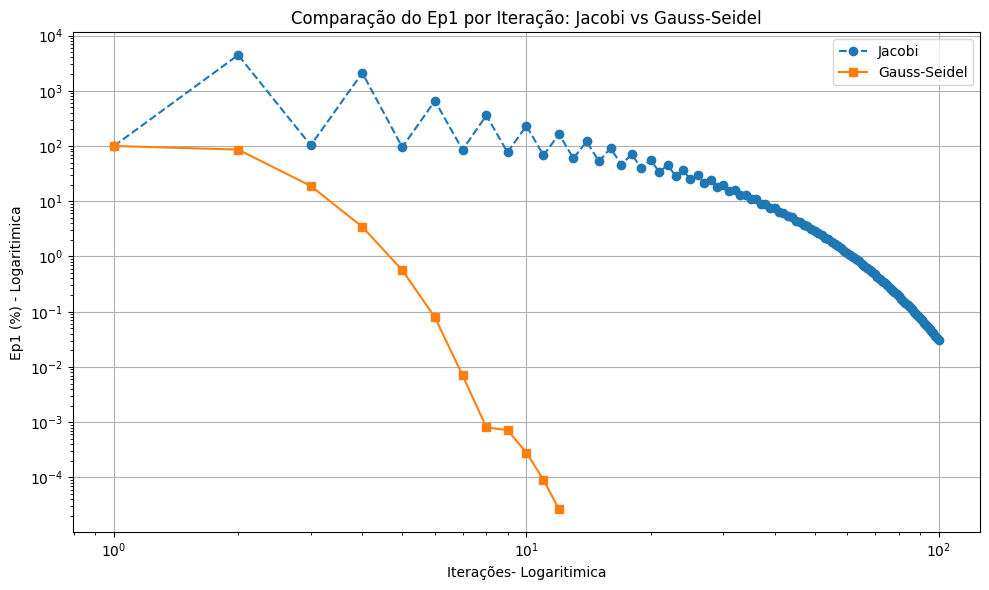

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dados do sistema
A = np.array([
    [0.52, 0.20, 0.25],
    [0.30, 0.50, 0.20],
    [0.18, 0.30, 0.55]
], dtype=float)

b = np.array([4800, 5800, 5700], dtype=float)

# Parâmetros
num_digitos = 6
Eppara = 0.5 * 10**(2 - num_digitos)
max_iter = 100
n = len(b)

# -------- Método de Jacobi --------
x_jacobi = np.zeros(n)
ep1_jacobi = []
iter_jacobi = []

for it in range(1, max_iter + 1):
    x_new = np.zeros(n)
    for i in range(n):
        soma = sum(A[i, j] * x_jacobi[j] for j in range(n) if j != i)
        x_new[i] = (b[i] - soma) / A[i, i]

    Epest = [abs((x_new[i] - x_jacobi[i]) / x_new[i]) * 100 if x_new[i] != 0 else 100 for i in range(n)]

    ep1_jacobi.append(Epest[0])
    iter_jacobi.append(it)

    if all(Ep < Eppara for Ep in Epest):
        break

    x_jacobi = x_new.copy()

# -------- Método de Gauss-Seidel --------
x_gs = np.zeros(n)
ep1_gs = []
iter_gs = []

for it in range(1, max_iter + 1):
    x_new = np.copy(x_gs)
    for i in range(n):
        soma = sum(A[i, j] * x_new[j] if j < i else A[i, j] * x_gs[j] for j in range(n) if j != i)
        x_new[i] = (b[i] - soma) / A[i, i]

    Epest = [abs((x_new[i] - x_gs[i]) / x_new[i]) * 100 if x_new[i] != 0 else 100 for i in range(n)]

    ep1_gs.append(Epest[0])
    iter_gs.append(it)

    if all(Ep < Eppara for Ep in Epest):
        break

    x_gs = x_new.copy()

# -------- Plotando os dois gráficos juntos --------
plt.figure(figsize=(10, 6))
plt.plot(iter_jacobi, ep1_jacobi, marker='o', label='Jacobi', linestyle='--')
plt.plot(iter_gs, ep1_gs, marker='s', label='Gauss-Seidel', linestyle='-')

plt.yscale('log')
plt.xscale('log')
plt.title("Comparação do Ep1 por Iteração: Jacobi vs Gauss-Seidel")
plt.xlabel("Iterações- Logaritimica")
plt.ylabel("Ep1 (%) - Logaritimica")


plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
